In [1]:
!pip install -q datasets transformers accelerate

In [7]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from datasets import load_dataset

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

cuda
Tesla T4


In [2]:
from datasets import load_dataset

dataset = load_dataset(
    "eltorio/ROCOv2-radiology",
    split="train"
)

print(dataset)

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

data/train-00000-of-00027.parquet:   0%|          | 0.00/497M [00:00<?, ?B/s]

data/train-00001-of-00027.parquet:   0%|          | 0.00/504M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/59962 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/9904 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/9927 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/27 [00:00<?, ?it/s]

Dataset({
    features: ['image', 'image_id', 'caption', 'cui'],
    num_rows: 59962
})


Image ID:
ROCOv2_2023_train_000001

Caption:
Head CT demonstrating left parotiditis.

CUI:
['C0040405']

Number of CUIs:
1

Image:


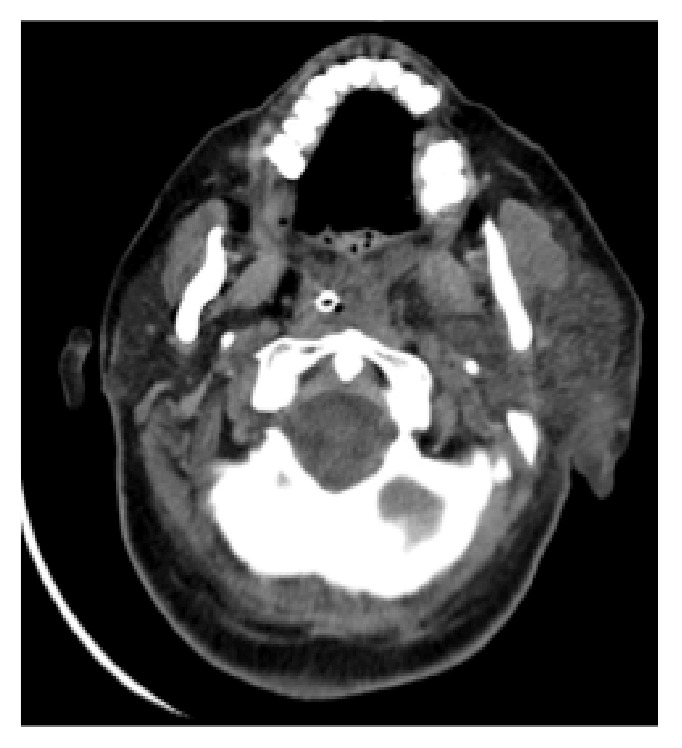

In [10]:
sample = dataset[0]

print("Image ID:")
print(sample["image_id"])

print("\nCaption:")
print(sample["caption"])

print("\nCUI:")
print(sample["cui"])

print("\nNumber of CUIs:")
print(len(sample["cui"]))

print("\nImage:")
display(sample["image"])

ID: ROCOv2_2023_train_000001
CUI: ['C0040405']
Caption: Head CT demonstrating left parotiditis.


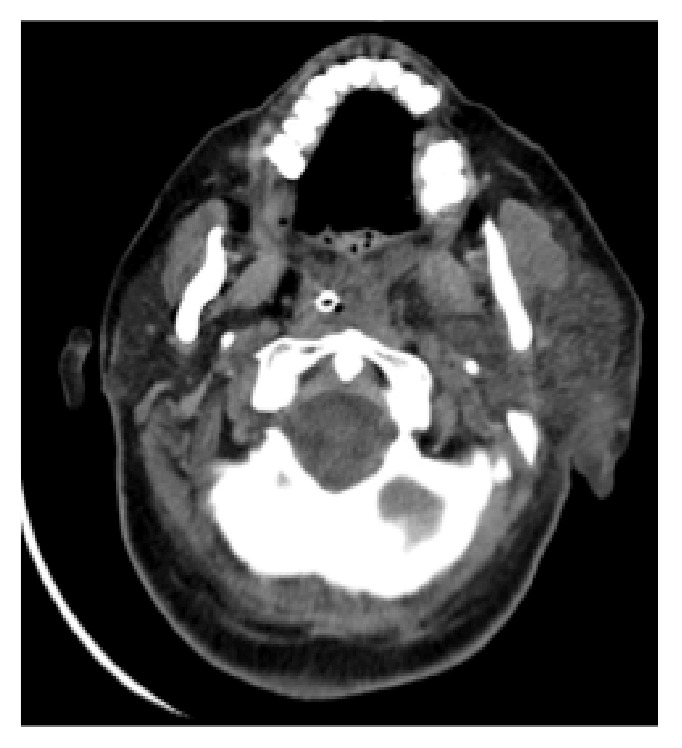

ID: ROCOv2_2023_train_000002
CUI: ['C0041618']
Caption: Acquired renal cysts in end-stage renal failure: 16-year-old girl with Alport syndrome and peritoneal dialysis from the age of 2 years


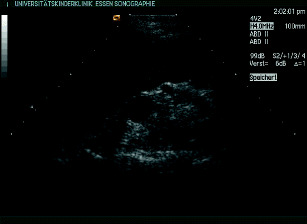

ID: ROCOv2_2023_train_000003
CUI: ['C0040405']
Caption: Computed tomography of the chest showing the right breast nodule with irregular margins


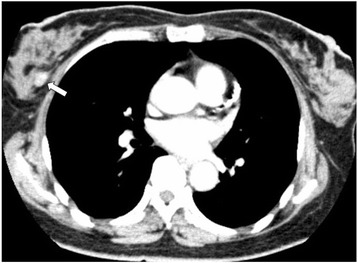

ID: ROCOv2_2023_train_000011
CUI: ['C0040405']
Caption: Postop 22-month CT scan (sagittal): Posteriorly the graft seated in a sound bone


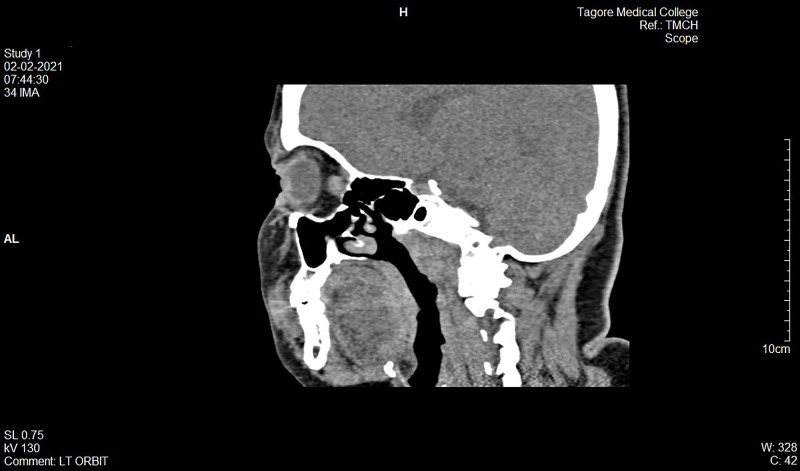

ID: ROCOv2_2023_train_000101
CUI: ['C1306645', 'C0037303', 'C0205129']
Caption: Lateral cephalogram of the patient.


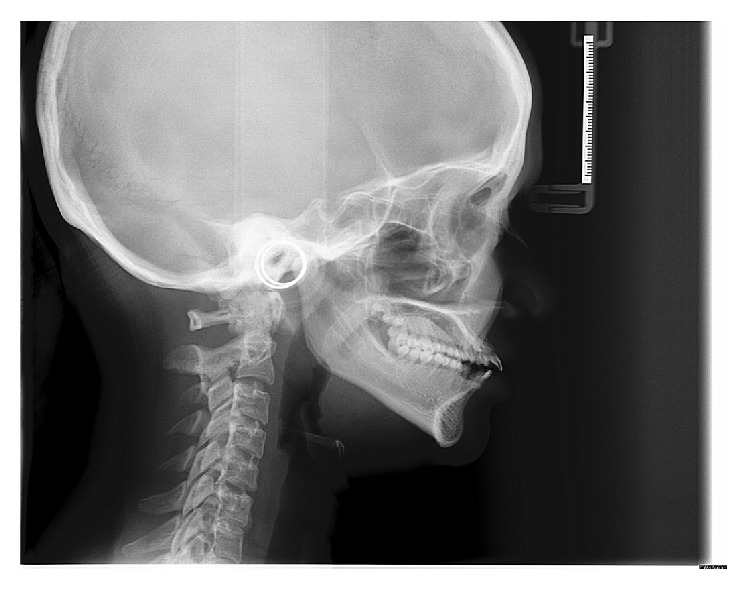

In [11]:
for i in [0, 1, 2, 10, 100]:
    sample = dataset[i]

    print("=" * 80)
    print("ID:", sample["image_id"])
    print("CUI:", sample["cui"])
    print("Caption:", sample["caption"])

    display(sample["image"])

In [12]:
from collections import Counter

cui_counter = Counter()

for row in dataset:
    cui_counter.update(row["cui"])

print("Number of unique CUIs:", len(cui_counter))

for cui, count in cui_counter.most_common(30):
    print(cui, count)

Number of unique CUIs: 20
C0040405 20459
C1306645 16603
C0024485 9790
C0041618 8305
C1999039 7111
C0817096 5463
C0002978 3958
C1996865 3393
C0037303 3216
C0023216 2293
C0205129 1868
C0000726 1747
C0030797 1257
C1140618 1119
C0037949 1073
nan 493
C0032743 350
C0006141 56
C0205106 29
C0037005 4
